In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv
import glob

In [23]:
# design file
des_fp = '/global/scratch/projects/fc_mvslab/data/sequencing/sog1_margot/sog_lib2/spikes/Sog1_lib2_dna.txt'
def find_designed(des):
    """ takes a file where every line is a designed tile and creates a lookup dictionary of all designed tiles """
    dt = [] # initialize a list of designed tiles from design file
    with open(des, 'r') as f_des:
        # open the design file for reading
        for line in f_des:
            if "ArrayDNA" in line: #skip the "arrayDNA" line if applicable
                pass
            else:
                dt.append(line.strip()) #add tile to list without whitespace
    
    dt_dict = {} # initialize dictionary to lookup tiles in
    for i in dt:
        dt_dict[i] = 1 # add tiles into a diction ary
        
    print('Number of designed tiles:', len(dt_dict)) 

    return dt_dict

dd = find_designed(des_fp)


def getmid(seq, pre, post, bclen):
    # seq = the sequence to parse
    # pre = substring that precedes piece of interest
    # post = substring that follows piece of interest
    # returns piece of interest

    re_key = pre + "(.*)"+ post 
    poi_search = re.search(re_key, seq)
    if poi_search is None:
        #the barcode will be called X
        poi = "X"
                    
    else:
        poi = poi_search.group(1)

    return poi

#putative consensus sequences ***reverse complement of snapgene***
adp = 'GGGCCCG'#7 bp ; beforeAD barcode in read1
adf = 'GGAGAGAA' #7bp ; after AD barcode in read1


# function that just looks for Tile/AD bc
def adbc_mapper(readfile, bc_pre=adp, bc_post=adf, bc_len=11):
    #readfile = fastq (ADBC fastqs are typically paired)
    # dtiles = dictionary of designed tiles, output of find_designed
    # *_pre or *_post = the consensus sequences before or after each feature, defaults defined above

    # make lists of reads
    readlist = []    
    with open(readfile, 'r') as fin:
        for line in fin:
            if line.startswith('@'):
                #look at next line to get read sequence, add to list
                seq = next(fin)
                seq = seq.strip()
                readlist.append(seq)
                
    #make lists of BCs from list of reads
    bc_list = []
    bc_lens = []       
    for read in seqlist:
        bc= getmid(read, bc_pre, bc_post, bc_len)
        bc_list.append(bc)
        bcl = len(bc)
        bc_lens.append(bcl)

    #make the dict/df
    BC_dict = {"BCs":bc_list, "Length":bc_lens} 
    BC_df = pd.DataFrame.from_dict(BC_dict)
    
    #label df with library name
    libname = '_'.join(readfile.split('/')[-1].split('_')[0:4])
    BC_df['Library'] = libname
    
    return BC_df


Number of designed tiles: 11470


In [ ]:
# list of 1-8 , 13-20
gfp1 = range(1, 9)
gfp2 = range(13, 21)
sog1dir = '/global/scratch/projects/fc_mvslab/data/sequencing/sog1_margot/sog_lib2/sort3/'


gfp1_list = []

for i in gfp1:
    print(i)
    for filename in os.listdir(sog1dir):
        # print(filename)
        if filename.startswith(f'Staller_MYS3_{i}_'):
            # print(filename, 'FOUND')
            fpath = sog1dir+filename
            analyzed = adbc_mapper(fpath)
            gfp1_list.append(analyzed)

    
gfp2_list = []

for i in gfp2:
    print(i)
    for filename in os.listdir(sog1dir):
        # print(filename)
        if filename.startswith(f'Staller_MYS3_{i}_'):
            print(filename, 'FOUND')
            fpath = sog1dir+filename
            analyzed = adbc_mapper(fpath)
            gfp2_list.append(analyzed)

1


In [1]:
pwd

'/global/scratch/projects/fc_mvslab/OpenProjects/EChase/sog1/EC_analysis'

In [13]:
# # read in spike in barcode map (from jordan)
# map_df = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/EChase/sog1/EC_analysis/sog1_lib2_barcode_map_EC.csv", nrows=1)  # Read only 1 row after headers
# barcode_dict = map_df.iloc[0].to_dict()  # Convert to dictionary

In [12]:
map_df

,AGCACAGTTTC,GCCTACCCTCA,TGCACCAGATG,GGTCAGAGTCC,ATGTAGCGTAA,GCCAGCAGGCT,CCCCTATTTGC,TGCCACCACTA,GGTGTCGAACA,AGAAACAACCC,...,CACCTTAGATG,AGCCTCCGACC,GATTCAAACAG,CCGCAGATAAA,CCTTTCATTTC,ACAGCACTAGA,CAAGCGCAACA,CAATGTAGTTC,CAGCCTCTGAC,CCGCAACTGAA
0,GAAGATCCAACTTGGTTTGATTCTGGTTCTCAATTTATCTTAAATT...,GGTGTTAACTTTGATCCATCTGATCCAGAAATTATTTGGCATTTGT...,AAAGATAGAGATAATGAGAATCAAGGTGAAGAAGATCCATCTGATT...,GACTTTAAGAGAGATTTGGAAGAATGTCAGAAGATTGTCTTGGATC...,GGTGATAAAGCTGAACAAGAAGTTGCTGAAGATATCTTTGCTGCTG...,TTGGATTTGCCAGATGATGATGCTCCAGAAGAAGCTGGTTTGGCTG...,AATTCTGTTGGTGATTCTAAATGGTGGGAAGGTGAAGATCAATTCT...,ATTGCTGATTATGCTCATTTGGGTCCAGAAGACTTTGCTGCTGCTG...,ATTATTTGGCATTTGTTGGCTAAAGCTGGTTTGGCTGGTTTGGCTG...,TTGGAACATGGTGCTGCTGCTGCTGCTGCTGCTGCTTTGGATGATA...,...,GTTGGTGATAATGATAATTGTGCTGAAGAAGGTACTAAATGGTGGG...,CAACAACCACAACAATTGGTTGTTAAGAGAGGTGATAAAGCTGAAC...,TTGAATCATGGTTTGAATAATGGTGCTAAGAATATGTTGAATAATA...,GCTGCTCCAACTTGGTTTGCTTCTGGTTCTCAATTTATCTTAAATT...,AAATGTCAACATGTTATTGATAATTCTGCTGTTGTTGCTGCTTGGC...,CAACAACCACAACAATTGGTTGTTAAGAGAGGTGATAAAGCTGAAC...,GAAGATCCAACTTGGTTTGATTCTGCTGCTGCTGCTATCTTAAATT...,AAATGTCAACATGTTATTGATAATTCTGCTGTTGTTGCTGCTTGGC...,AAAGATAGAGATAATGAGAATCAAGGTGAAGAAGATCCAACTTGGT...,AATCCATTGGATGATGGTTCTGCTTGGGCTGCTGCTGCTGCTCAAT...


In [23]:
len(barcode_dict)

500761

In [14]:
ls

EC_Sog1_GCN4analysis_LeBlanc2024.ipynb
MYS3_spikein_analysis.ipynb
Margot_lib2_spikein-ECtrial.ipynb
Sog1_all_activities_and_tiles_EC_unpublisheddatadownload.csv
Sog1_lib2_dna.txt*
Sog1_library2_activities_with_reads_ECspike.csv
counter_outputs/
slurm-23706279.out
slurm-23706300.out
slurm-23706321.out
slurm-23706330.out
sog1_lib2_barcode_map_EC.csv
testgfp1_activity_EC.csv
testgfp1_bins_EC.csv
testgfp1_losstable_EC.txt
testgfp1_readsseries_EC.csv
testgfp2_activity_EC.csv
testgfp2_bins_EC.csv
testgfp2_losstable_EC.txt
testgfp2_readsseries_EC.csv
to_local/


# Analyze counter_outputs

In [15]:
bc_counter_nextseq = "counter_outputs/counter_outputsStaller_MYS3_1_MVS_0001_I1_MVS_0001_I2_AACGCAATTC_CGTATCCGTA_S2_R1_001_BC_test.csv"
tile_counter_nextseq = "counter_outputs/counter_outputsStaller_MYS3_1_MVS_0001_I1_MVS_0001_I2_AACGCAATTC_CGTATCCGTA_S2_R1_001_TILE_test.csv"

In [18]:
bc_nextseq_df = pd.read_csv(bc_counter_nextseq, index_col=0)
bc_nextseq_df.head()

,BCs,count,Library
0,GTCTACCCTCA,117424,Staller_MYS3_1_MVS
1,ATGCACCATAT,89788,Staller_MYS3_1_MVS
2,CACAGGCCACT,62922,Staller_MYS3_1_MVS
3,GCCATAGCACA,52208,Staller_MYS3_1_MVS
4,GCATAGTCCGT,48807,Staller_MYS3_1_MVS


/global/home/users/empchase/.conda/envs/js_code/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='count', ylabel='Count'>

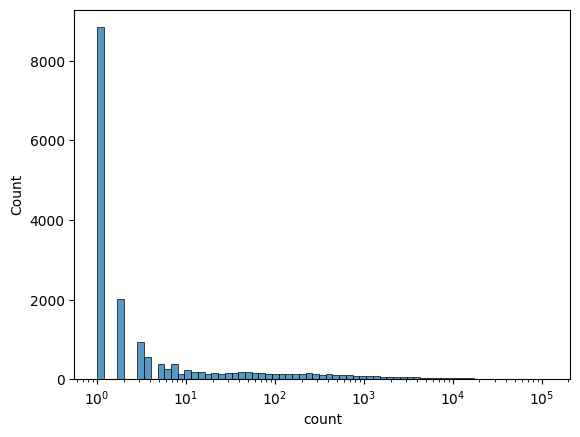

In [20]:
sns.histplot(bc_nextseq_df, x='count', log_scale=True)

/global/home/users/empchase/.conda/envs/js_code/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='count', ylabel='Count'>

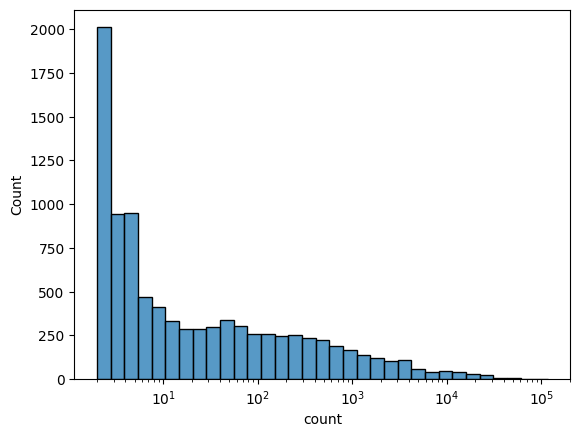

In [27]:
sns.histplot(bc_nextseq_df[bc_nextseq_df['count']>1], x='count', log_scale=True)

In [21]:
tile_nextseq_df = pd.read_csv(tile_counter_nextseq, index_col=0)
tile_nextseq_df.head()

,Tile,count,Library
0,CATTTGAAGAGACATGTTAGATCTGTTCATTCTAATGAAAGACCAT...,119109,Staller_MYS3_1_MVS
1,GACCCAGTTGCTCCTAAATTGGCTGAACCAGAACCAAGAAATGCTG...,89791,Staller_MYS3_1_MVS
2,TTGTCTGGTTTGTCTTCTCATCCAGCTATTGATGAAGCTATTCCAA...,62922,Staller_MYS3_1_MVS
3,TTGGAACATGGTTTGGAGAATGGTGCTAAAGAAATGGCTGATGATA...,52512,Staller_MYS3_1_MVS
4,ACTGGATTTGCTGATTCTTTGGAAACTATGTTGGAAGGTCATGAAG...,48808,Staller_MYS3_1_MVS


/global/home/users/empchase/.conda/envs/js_code/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='count', ylabel='Count'>

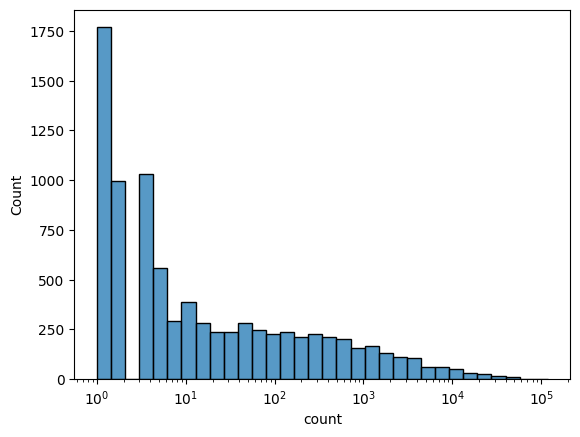

In [22]:
sns.histplot(tile_nextseq_df, x='count', log_scale=True)

In [24]:
bc_counter_CZB = 'counter_outputs/MYS3_001_S1_R1_001_BC_test.csv'
tile_counter_CZB = 'counter_outputs/MYS3_001_S1_R1_001_TILE_test.csv'

/global/home/users/empchase/.conda/envs/js_code/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='count', ylabel='Count'>

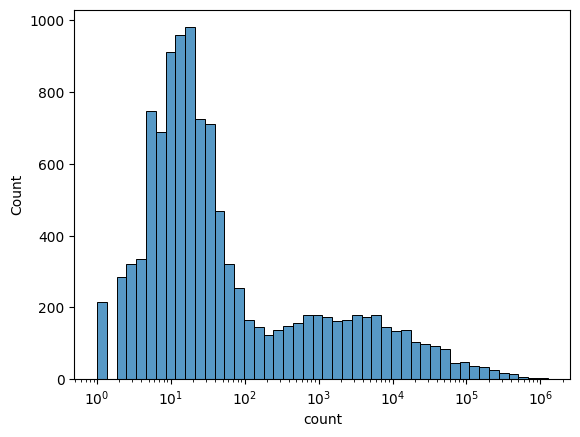

In [25]:
tile_CZB_df = pd.read_csv(tile_counter_CZB, index_col=0)
sns.histplot(tile_CZB_df, x='count', log_scale=True)

/global/home/users/empchase/.conda/envs/js_code/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='count', ylabel='Count'>

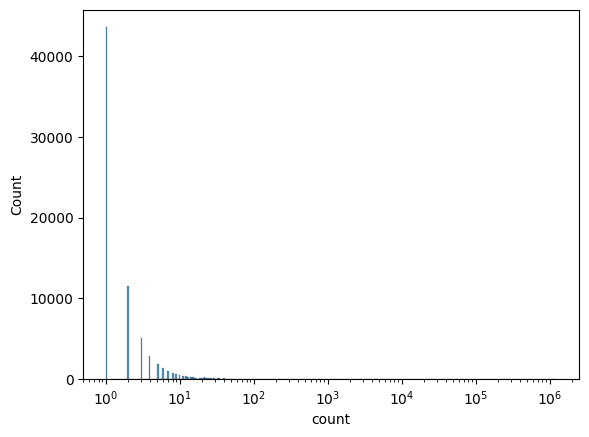

In [26]:
bc_CZB_df = pd.read_csv(bc_counter_CZB, index_col=0)
sns.histplot(bc_CZB_df, x='count', log_scale=True)

/global/home/users/empchase/.conda/envs/js_code/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='count', ylabel='Count'>

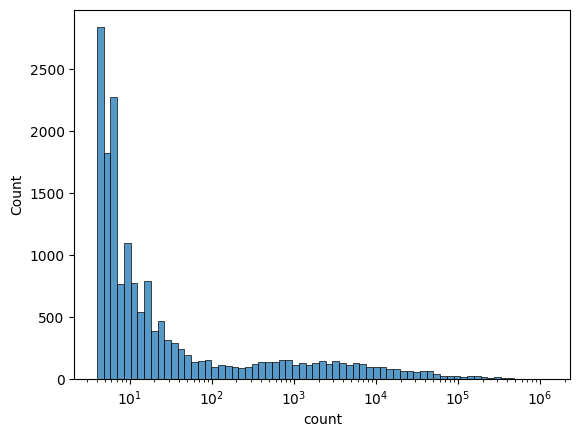

In [29]:
sns.histplot(bc_CZB_df[bc_CZB_df['count']>3] , x='count', log_scale=True)